## 1. Configuracion

In [9]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print('Configuracion lista')

Configuracion lista


## 2. Descargar Datos

In [10]:
from src.data.collector import DataCollector

collector = DataCollector()
df = collector.download_ticker('AAPL', years=1)

print(f'Datos: {len(df)} filas')
print(f'Periodo: {df.index.min().date()} a {df.index.max().date()}')
df.head()

2026-01-08 15:17:34 - src.data.collector - INFO - descargando AAPL...


2026-01-08 15:17:35 - src.data.collector - INFO - guardado AAPL: 251 dias
Datos: 251 filas
Periodo: 2025-01-08 a 2026-01-08


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-08 00:00:00-05:00,240.830782,242.612732,238.969207,241.607269,37628900,0.0,0.0
2025-01-10 00:00:00-05:00,238.929361,239.078694,231.950928,235.783600,61710900,0.0,0.0
2025-01-13 00:00:00-05:00,232.478542,233.613408,228.685699,233.344620,49630700,0.0,0.0
2025-01-14 00:00:00-05:00,233.693058,235.056885,231.423325,232.229675,39435300,0.0,0.0
2025-01-15 00:00:00-05:00,233.583558,237.884115,233.374497,236.799011,39832000,0.0,0.0


## 3. Calcular Indicadores Tecnicos

In [11]:
from src.data.processor import TechnicalProcessor

processor = TechnicalProcessor()
df_processed = processor.process_all_indicators(df)

print(f'Columnas: {df_processed.shape[1]}')
print(f'Indicadores: returns, volatility, sma_10, sma_20, sma_50, rsi, volume_ratio')
df_processed.tail()

2026-01-08 15:17:35 - src.data.processor - INFO - calculando indicadores tecnicos
2026-01-08 15:17:36 - src.data.processor - INFO - indicadores calculados
Columnas: 23
Indicadores: returns, volatility, sma_10, sma_20, sma_50, rsi, volume_ratio


,Open,High,Low,Close,Volume,Dividends,Stock Splits,retorno_1d,retorno_5d,retorno_20d,...,sma_20,sma_50,dist_sma_10,dist_sma_20,rsi,volumen_sma_20,volumen_ratio,dia_semana,mes,trimestre
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-02 00:00:00-05:00,272.260010,277.839996,269.000000,271.010010,37838100,0.0,0.0,-0.003127,-0.010226,-0.046243,...,274.815498,272.759640,-0.005873,-0.013847,31.108797,40928550.00,0.924492,4,1,1
2026-01-05 00:00:00-05:00,270.640015,271.510010,266.140015,267.260010,45647200,0.0,0.0,-0.013837,-0.022458,-0.047880,...,274.143498,272.940846,-0.017853,-0.025109,25.045369,41011455.00,1.113035,0,1,1
2026-01-06 00:00:00-05:00,267.000000,267.549988,262.119995,262.359985,52352100,0.0,0.0,-0.018334,-0.041642,-0.058900,...,273.322498,273.001474,-0.031836,-0.040108,24.243819,41265770.00,1.268657,1,1,1
2026-01-07 00:00:00-05:00,263.200012,263.679993,259.809998,260.329987,48262000,0.0,0.0,-0.007737,-0.046690,-0.063191,...,272.444496,272.956764,-0.035540,-0.044466,20.665643,41768280.00,1.155470,2,1,1
2026-01-08 00:00:00-05:00,256.994995,258.600006,255.699997,256.809998,28791267,0.0,0.0,-0.013521,-0.055359,-0.073490,...,271.425996,272.721971,-0.043068,-0.053849,20.047899,41598178.35,0.692128,3,1,1


## 4. Grafico de Precio y Medias Moviles

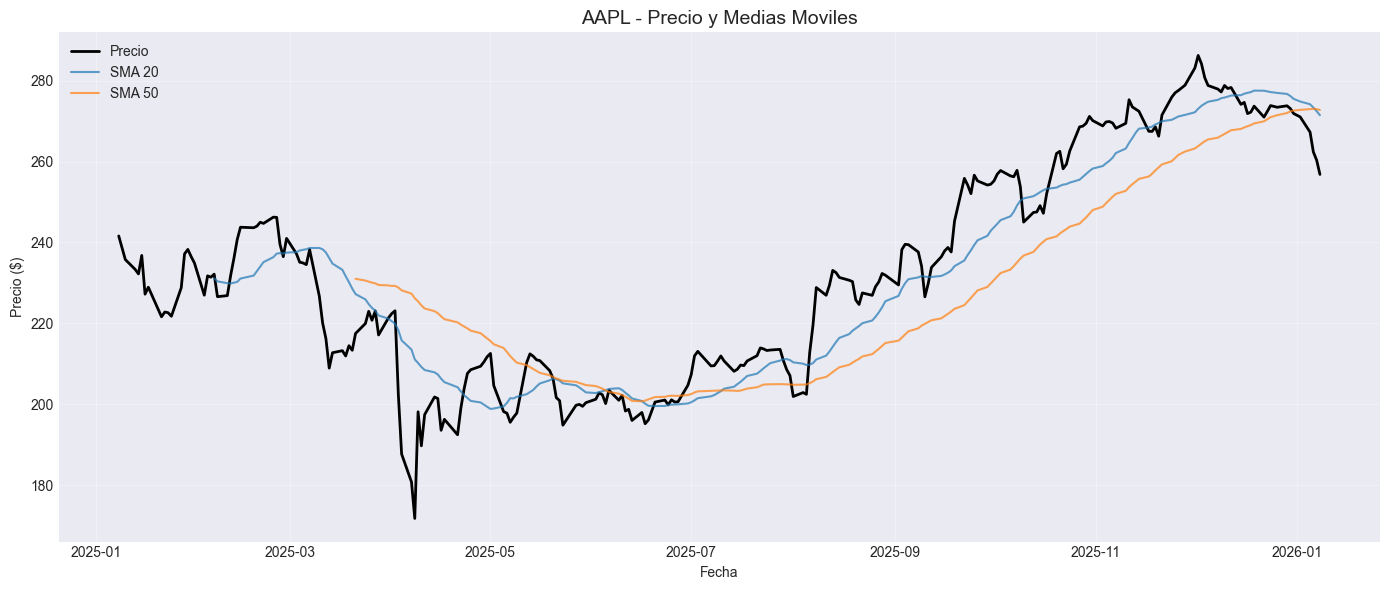

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_processed.index, df_processed['Close'], label='Precio', linewidth=2, color='black')
ax.plot(df_processed.index, df_processed['sma_20'], label='SMA 20', alpha=0.7)
ax.plot(df_processed.index, df_processed['sma_50'], label='SMA 50', alpha=0.7)

ax.set_title('AAPL - Precio y Medias Moviles', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Grafico de RSI

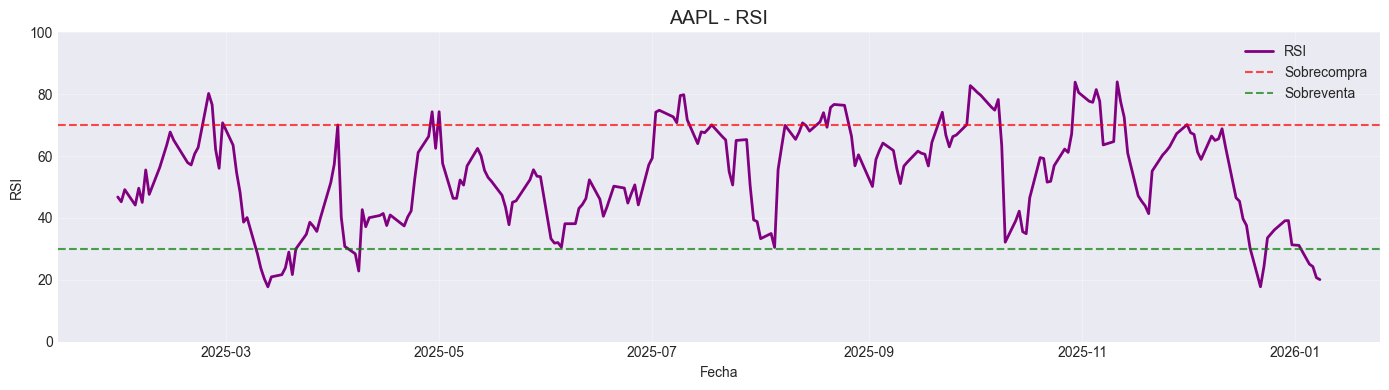

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_processed.index, df_processed['rsi'], label='RSI', linewidth=2, color='purple')
ax.axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Sobrecompra')
ax.axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Sobreventa')

ax.set_title('AAPL - RSI', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Preparar Datos para ML

In [16]:
from src.ml.trainer import ModelTrainer

# limpiar datos NaN
df_processed = df_processed.dropna()

# crear la columna target
df_processed['target_direccion'] = (df_processed['Close'].shift(-1) > df_processed['Close']).astype(int)

# limpiar NaN de nuevo
df_processed = df_processed.dropna()

print(f'Columnas disponibles: {list(df_processed.columns)}')

trainer = ModelTrainer()
X, y = trainer.prepare_features(df_processed)

if X is not None and y is not None:
    print(f'\nFeatures (X): {X.shape}')
    print(f'Target (y): {y.shape}')
    print(f'\nDistribucion:')
    print(f'  Subida (1): {(y == 1).sum()}')
    print(f'  Bajada (0): {(y == 0).sum()}')
else:
    print('Error: no se pudieron preparar las features')

Columnas disponibles: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'retorno_1d', 'retorno_5d', 'retorno_20d', 'volatilidad_5d', 'volatilidad_20d', 'sma_10', 'sma_20', 'sma_50', 'dist_sma_10', 'dist_sma_20', 'rsi', 'volumen_sma_20', 'volumen_ratio', 'dia_semana', 'mes', 'trimestre', 'target_direccion']
2026-01-08 15:21:50 - src.ml.trainer - INFO - features: 11, muestras: 202
2026-01-08 15:21:50 - src.ml.trainer - INFO - distribucion target: {1: np.int64(107), 0: np.int64(95)}

Features (X): (202, 11)
Target (y): (202,)

Distribucion:
  Subida (1): 107
  Bajada (0): 95


## 7. Entrenar Modelo

In [17]:
accuracy = trainer.train(X, y)

print(f'Modelo: RandomForestClassifier')
print(f'Accuracy: {accuracy:.2%}')

2026-01-08 15:21:58 - src.ml.trainer - INFO - iniciando entrenamiento
2026-01-08 15:21:58 - src.ml.trainer - INFO - train: 161, test: 41
2026-01-08 15:21:59 - src.ml.trainer - INFO - precision: 41.46%
2026-01-08 15:21:59 - src.ml.trainer - INFO - aciertos: 17/41
2026-01-08 15:21:59 - src.ml.trainer - INFO - 
              precision    recall  f1-score   support

        BAJA       0.50      0.25      0.33        24
        SUBE       0.38      0.65      0.48        17

    accuracy                           0.41        41
   macro avg       0.44      0.45      0.41        41
weighted avg       0.45      0.41      0.39        41

2026-01-08 15:22:00 - src.ml.trainer - INFO - 
features mas importantes:
2026-01-08 15:22:00 - src.ml.trainer - INFO -   volatilidad_5d: 0.1496
2026-01-08 15:22:00 - src.ml.trainer - INFO -   dist_sma_20: 0.1209
2026-01-08 15:22:00 - src.ml.trainer - INFO -   retorno_20d: 0.1188
2026-01-08 15:22:00 - src.ml.trainer - INFO -   retorno_1d: 0.1059
2026-01-08 15:22

## 8. Prediccion Individual

In [19]:
from src.ml.predictor import StockPredictor

predictor = StockPredictor()
resultado = predictor.predict_ticker('AAPL')

if resultado:
    print(f"Ticker: {resultado['ticker']}")
    print(f"Prediccion: {'SUBIDA' if resultado['prediction'] == 1 else 'BAJADA'}")
    print(f"Confianza: {resultado['confidence']:.1%}")
    print(f"Precio: ${resultado['current_price']:.2f}")
    if 'recommendation' in resultado:
        print(f"Recomendacion: {resultado['recommendation']}")
else:
    print('Error en la prediccion')

2026-01-08 15:23:33 - src.ml.trainer - INFO - modelo cargado: c:\Users\Federico\Desktop\prediction_api\models\modelo_basico.pkl
2026-01-08 15:23:34 - src.data.processor - INFO - calculando indicadores tecnicos
2026-01-08 15:23:34 - src.data.processor - INFO - indicadores calculados
2026-01-08 15:23:34 - src.ml.predictor - INFO - prediccion AAPL: SUBE (56.9%)
Ticker: AAPL
Prediccion: SUBIDA
Confianza: 56.9%
Precio: $257.20


## 9. Predicciones Multiples

In [21]:
tickers = ['AAPL', 'GOOGL', 'MSFT', 'TSLA', 'AMZN']

resultados = []
for ticker in tickers:
    res = predictor.predict_ticker(ticker)
    if res:
        resultados.append(res)

if resultados:
    df_pred = pd.DataFrame(resultados)
    df_pred['pred'] = df_pred['prediction'].apply(lambda x: 'SUBIDA' if x == 1 else 'BAJADA')
    df_pred['conf'] = df_pred['confidence'].apply(lambda x: f'{x:.1%}')
    
    print(f'\nResultados para {len(df_pred)} acciones:')
    
    # Mostrar solo las columnas que existen
    cols_to_show = ['ticker', 'pred', 'conf', 'current_price']
    if 'recommendation' in df_pred.columns:
        cols_to_show.append('recommendation')
    
    print(df_pred[cols_to_show])
else:
    print('No se obtuvieron predicciones')

2026-01-08 15:24:51 - src.data.processor - INFO - calculando indicadores tecnicos
2026-01-08 15:24:51 - src.data.processor - INFO - indicadores calculados
2026-01-08 15:24:51 - src.ml.predictor - INFO - prediccion AAPL: SUBE (56.9%)
2026-01-08 15:24:52 - src.data.processor - INFO - calculando indicadores tecnicos
2026-01-08 15:24:52 - src.data.processor - INFO - indicadores calculados
2026-01-08 15:24:52 - src.ml.predictor - INFO - prediccion GOOGL: BAJA (51.4%)
2026-01-08 15:24:53 - src.data.processor - INFO - calculando indicadores tecnicos
2026-01-08 15:24:53 - src.data.processor - INFO - indicadores calculados
2026-01-08 15:24:53 - src.ml.predictor - INFO - prediccion MSFT: SUBE (55.1%)
2026-01-08 15:24:53 - src.data.processor - INFO - calculando indicadores tecnicos
2026-01-08 15:24:53 - src.data.processor - INFO - indicadores calculados
2026-01-08 15:24:53 - src.ml.predictor - INFO - prediccion TSLA: BAJA (58.1%)
2026-01-08 15:24:54 - src.data.processor - INFO - calculando indica

## 10. Evaluacion del Modelo

In [22]:
from src.ml.evaluator import ModelEvaluator
from sklearn.model_selection import train_test_split

evaluator = ModelEvaluator()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if trainer.model:
    y_pred = trainer.model.predict(X_test)
    metricas = evaluator.evaluate_classification(y_test, y_pred)
    
    print('\nMetricas del Modelo:')
    print('=' * 30)
    print(f"Accuracy:  {metricas['accuracy']:.2%}")
    print(f"Precision: {metricas['precision']:.2%}")
    print(f"Recall:    {metricas['recall']:.2%}")
    print(f"F1 Score:  {metricas['f1_score']:.2%}")
    print('=' * 30)
    print(f'\nTest: {len(X_test)} | Train: {len(X_train)}')

2026-01-08 15:25:07 - src.ml.evaluator - INFO - metricas de evaluacion:
2026-01-08 15:25:07 - src.ml.evaluator - INFO -   accuracy: 0.8049
2026-01-08 15:25:07 - src.ml.evaluator - INFO -   precision: 0.8627
2026-01-08 15:25:07 - src.ml.evaluator - INFO -   recall: 0.8049
2026-01-08 15:25:07 - src.ml.evaluator - INFO -   f1_score: 0.8002

Metricas del Modelo:
Accuracy:  80.49%
Precision: 86.27%
Recall:    80.49%
F1 Score:  80.02%

Test: 41 | Train: 161


# 11. Sistema Avanzado - Ensemble 70%+ Accuracy

Sistema con 4 modelos ensamblados (XGBoost, LightGBM, RandomForest, ExtraTrees) + 50+ features + optimizacion Optuna

In [ ]:
# entrenar ensemble avanzado
from src.ml.advanced_trainer import AdvancedEnsemble

trainer_adv = AdvancedEnsemble()
results = trainer_adv.train(df_processed, optimize=False)  # cambiar a True para optimizar

print("\n🎯 RESULTADOS:")
print(f"Accuracy:  {results['test_accuracy']*100:.2f}%")
print(f"Precision: {results['precision']*100:.2f}%")
print(f"Features:  {results['n_features']}")

In [ ]:
# prediccion con filtro de confianza >75%
from src.ml.advanced_predictor import AdvancedPredictor

predictor_adv = AdvancedPredictor(confidence_threshold=0.75)
resultado = predictor_adv.predict_ticker('AAPL')

print("\n📊 PREDICCION AVANZADA:")
print(f"Ticker:      {resultado['ticker']}")
print(f"Prediccion:  {resultado['prediccion'].upper()}")
print(f"Confianza:   {resultado['confianza']*100:.2f}%")
print(f"Prob Subida: {resultado['probabilidad_subida']*100:.2f}%")
print(f"Mensaje:     {resultado['mensaje']}")